# Representing Data and Engineering Features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #; sns.set_theme()
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## Categorical Variables - Adult incomes in the US

**Task**: Predict whether a worker has an income of over $\text{\$}$50,000 or under $\text{\$}$50,000.

In [2]:
# Import dataset
from sklearn.datasets import fetch_openml
adult_raw = fetch_openml(name='adult', data_home='~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/adult', version=2)

In [3]:
# Show first 10 entries of data
adult_raw.data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States


The task is a classification task, but it is also possible to predict the exact income (a regression task). That is much more difficult, and the classification task is interesting on its own.

In [4]:
# Data types of the features
adult_raw.data.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object

## One-Hot-Encoding, aka One-Out-of-N Encoding, aka Dummy Variables

I will use **one-hot-encoding**, a.k.a. **dummy variables** to represent the above categorical features. To be able to follow the book's demonstration, I will drop some of the columns the authors did not include.

In [5]:
adult = adult_raw.data.drop(columns=['fnlwgt', 'education-num', 'marital-status', 'relationship',
                                     'race', 'capital-gain', 'capital-loss', 'native-country'])

In [6]:
adult.head()

,age,workclass,education,occupation,sex,hours-per-week
0,25,Private,11th,Machine-op-inspct,Male,40
1,38,Private,HS-grad,Farming-fishing,Male,50
2,28,Local-gov,Assoc-acdm,Protective-serv,Male,40
3,44,Private,Some-college,Machine-op-inspct,Male,40
4,18,NaN,Some-college,NaN,Female,30


In one-hot encoding, a new feature is created for each category, and the value of the new feature is 1 for samples that belong to the corresponding category, and 0 otherwise.

The Pandas function `get_dummies()` automatically does the encoding for all categorical columns in a Dataframe.

In [7]:
X = pd.get_dummies(adult, dtype=int)

In [8]:
print("Original features \n", list(adult.columns))
print("Encoded features \n", list(X.columns))

Original features 
 ['age', 'workclass', 'education', 'occupation', 'sex', 'hours-per-week']
Encoded features 
 ['age', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv'

Data has now been prepared in a form that is appropriate for use with Scikit-learn. We can now proceed to training a classifier on the data.

In [9]:
X = X.to_numpy()
y = adult_raw.target.to_numpy()
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (48842, 42) y shape: (48842,)


There are two classes in the dataset, so a binary classifier such as logistic regression is appropriate.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
logreg_score = LogisticRegression().fit(X_train,y_train).score(X_test,y_test)
print(f'Test score: {logreg_score:.2f}')

Test score: 0.81


## Numbers Can Encode Categoricals

For categorical features that are encoded using integers, Pandas' `get_dummies()` function will treat them as numeric and will not create dummy variables for them.

Some work arounds:
- Use Scikit-learn's `OneHotEncoder` so that you can specify which numeric features are discrete or continuous
- Convert the column to string or explicitly specify the columns to be encoded in the `get_dummies()` function

### Example - Adult dataset
The adult dataset has a column `education-num` which is equivalent to the categorical column `education` but encoded using integers.

In [11]:
educ_data = adult_raw.data[['education', 'education-num']]

for col in educ_data.columns:
    print(educ_data[col].value_counts())
    print('')

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64



Here, the levels of education are encoded using integers 1 to 16 with 1 being the lowest level of education, Preschool; and 16 being the highest, Doctorate.

In [12]:
educ_data.dtypes

education        category
education-num       int64
dtype: object

If we use `get_dummies()`, the 'education-num' will be treated as continuous and no dummies will be created for the feature.

In [13]:
pd.get_dummies(educ_data, dtype=int).head()

,education-num,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college
0,7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,12,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


If we intend to also apply one-hot-encoding to the `education-num` feature, either convert the column to type `str` *or* explicitly specify the columns to be encoded in the `get_dummies()` function.

In [14]:
educ_data1 = educ_data.copy()
# Workaround 1: Converting to str
educ_data1['education-num'] = educ_data1['education-num'].astype(str)
print('Workaround 1 shape:', pd.get_dummies(educ_data1, dtype=int).shape)

# Workaround 2: Specify in get_dummies function
print('Workaround 2 shape:', pd.get_dummies(educ_data, dtype=int, columns=educ_data.columns).shape)

Workaround 1 shape: (48842, 32)
Workaround 2 shape: (48842, 32)


### Scikit-Learn's `OneHotEncoder()`

Another way to apply one-hot-encoding to a categorical feature that is encoded as integers, is to use Scikit-learn's `OneHotEncoder`

In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int).fit(educ_data)
pd.DataFrame(
    encoder.transform(educ_data),
    columns = encoder.get_feature_names_out()
)

,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,...,education-num_7,education-num_8,education-num_9,education-num_10,education-num_11,education-num_12,education-num_13,education-num_14,education-num_15,education-num_16
0,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
48838,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
48839,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
48840,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


Ensure to only pass categorical features in the `OneHotEncoder` because it will not be able to distinguish continuous features.

Using Scikit-learn's `ColumnTransformer` along with `OneHotEncoder` allows us to pass the entire features matrix and encode only the categorical features.

In [16]:
from sklearn.compose import ColumnTransformer

cols = [col for col in adult.columns if adult[col].dtype == 'category']
cats = [adult[col].cat.categories for col in cols]
transformer = ColumnTransformer(
    [(
        'OneHotEncoder',
        OneHotEncoder(sparse_output=False, dtype=int, categories=cats, handle_unknown='ignore'),
        cols,
    )],
    remainder = 'passthrough'
)
transformer.fit(adult)

# For purposes of demonstration, convert the transformed output to a pandas dataframe
# But in practice there is obviously no need to do this...
adult_encoded = pd.DataFrame(transformer.transform(adult), columns=transformer.get_feature_names_out())
adult_encoded

,OneHotEncoder__workclass_Federal-gov,OneHotEncoder__workclass_Local-gov,OneHotEncoder__workclass_Never-worked,OneHotEncoder__workclass_Private,OneHotEncoder__workclass_Self-emp-inc,OneHotEncoder__workclass_Self-emp-not-inc,OneHotEncoder__workclass_State-gov,OneHotEncoder__workclass_Without-pay,OneHotEncoder__education_10th,OneHotEncoder__education_11th,...,OneHotEncoder__occupation_Priv-house-serv,OneHotEncoder__occupation_Prof-specialty,OneHotEncoder__occupation_Protective-serv,OneHotEncoder__occupation_Sales,OneHotEncoder__occupation_Tech-support,OneHotEncoder__occupation_Transport-moving,OneHotEncoder__sex_Female,OneHotEncoder__sex_Male,remainder__age,remainder__hours-per-week
0,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,25,40
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,38,50
2,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,28,40
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,44,40
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,18,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,27,38
48838,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,40,40
48839,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,58,40
48840,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,22,20


## Binning, Discretization, Linear Models, and Trees

Finding the best representation of data does not only depend on the real-world meaning of the data, but also on the kind of model to be used.

Consider the following wave data modelled with a linear regression model and a random forest regressor.

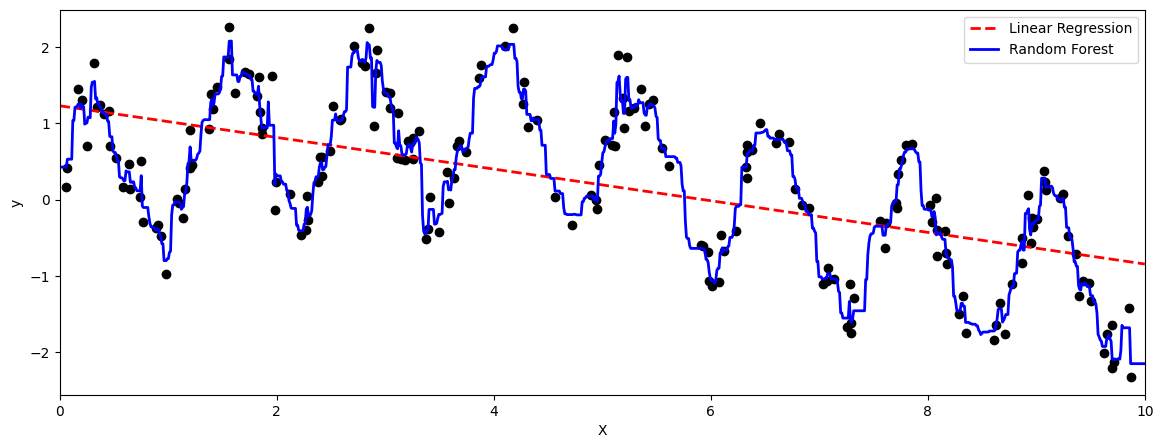

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

rng = np.random.RandomState(42)
X = 10 * rng.rand(200)
def func(X, sigma=0.3):
    fast_oscillation = 1 * np.sin(5 * X)
    slow_oscillation = np.sin(0.5 * X)
    noise = sigma * rng.randn(len(X))
    return slow_oscillation + fast_oscillation + noise
    
y = func(X, sigma=0.3)

# Plot raw data
plt.figure(figsize=(14,5))
plt.scatter(X, y, c='k')

line = np.linspace(0,10,1000).reshape(-1,1)
# Linear Regression
plt.plot(line, LinearRegression().fit(X[:,np.newaxis],y).predict(line), ls='--', c='r', label='Linear Regression', linewidth=2)

# Random Forest Regressor
plt.plot(line, RandomForestRegressor(n_estimators=100).fit(X[:,np.newaxis], y).predict(line), 
         c='blue', label='Random Forest', linewidth=2)

plt.legend()
plt.xlim(0,10)
plt.xlabel('X')
plt.ylabel('y');

Here we can see that a simple linear model does not perform as good as the random forest regression model. The random forest model is more flexible, and captures the nonlinear relationship very well.

However, this difference in flexibility is largely dependent on the representation of the data. One way to make linear models perform better on nonlinear data is to discretize the data.

In [18]:
bins = np.linspace(-0.001,10.001,11) # Bin the data with 10 bins
X_binned = np.digitize(X, bins) # X_binned[i] is the bin where X[i] is contained

encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoder.fit(X_binned.reshape(-1,1))
X_binned_1 = encoder.transform(X_binned.reshape(-1,1))
X_binned_1.shape

(200, 10)

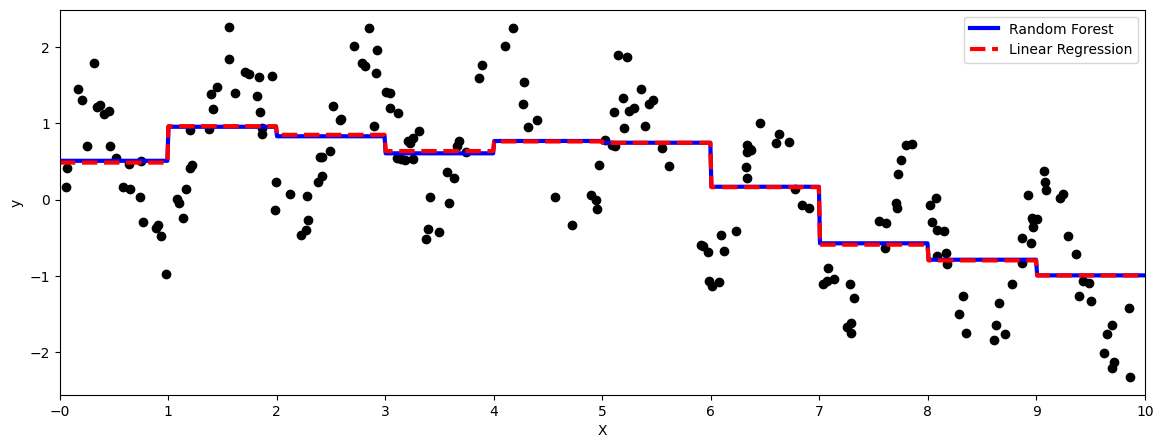

In [19]:
# Plot raw data
plt.figure(figsize=(14,5))
plt.scatter(X, y, c='k')

line_binned = encoder.transform(np.digitize(line, bins))

# Random Forest Regressor
plt.plot(line, RandomForestRegressor(n_estimators=100).fit(X_binned_1, y).predict(line_binned), 
         c='blue', label='Random Forest', linewidth=3)

# Linear Regression
plt.plot(line, LinearRegression().fit(X_binned_1,y).predict(line_binned), ls='--', c='r', label='Linear Regression', linewidth=3)

plt.legend()
plt.xlim(0,10)
plt.xticks(bins)
plt.xlabel('X')
plt.ylabel('y');

After discretization of the data (converting the continuous input feature to a categorical feature), we see that the linear model and the random forest model are now at the same level. The linear model is now more flexible on the data, while the random forest became less flexible.

Random forest generally don't benefit from discretization -- it can learn on its own about whatever binning is most useful for the data.

The linear model on the other hand, benefited greatly from the discretization. So, if there is a good reason to use linear models, discretization is a great way to improve flexibility.

## Interactions and Polynomials

Another way to enrich feature representation, particularly for linear models, is to add **interaction** features or **polynomial** features.

In the previous feature representation, we binned the continuous feature to become a categorical feature. This resulted the linear model to predict a constant value depending on which bin the point belongs to.

In a way, the linear model has provided a best-fit horizontal line for each bin. But we know linear model can do better than horizontal lines!

We can make the model find a best-fit line for each bin with a slope. A way to do this is to add the original features to the binned columns. In otherwords, we consider.

$$\mathbf{X}_1 = [\mathbf{X},\mathbf{X}_{\text{binned}}]$$

Features matrix shape: (200, 11)


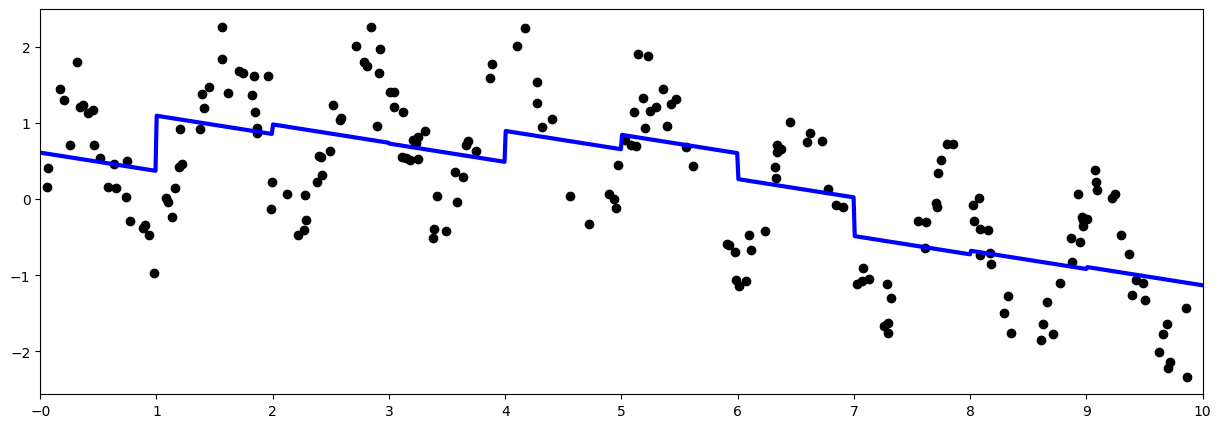

In [20]:
X1 = np.hstack([X.reshape(-1,1),X_binned_1])
print('Features matrix shape:', X1.shape)
model1 = LinearRegression().fit(X1, y)

line1 = np.hstack([line.reshape(-1,1), line_binned])
ypred = model1.predict(line1)

plt.figure(figsize=(15,5))
plt.scatter(X, y, c='k')
plt.plot(line, ypred, c='blue', linewidth=3, label='linear model')
plt.xlim(0,10)
plt.xticks(bins);

Combining the original feature and the binned features resulted in the linear model learning the appropriate slope for all bins. But, this slope is the same for all bins. A more flexible model would consider different slopes for each bin!

A feature representation that enables the linear model to do this is a combination of the binned features `X_binned` and the product `X * X_binned`:

$$\mathbf{X}_2 = [\mathbf{X}_{\text{binned}},\, \mathbf{X}\cdot\mathbf{X}_{\text{binned}}]$$

Features matrix shape: (200, 20)


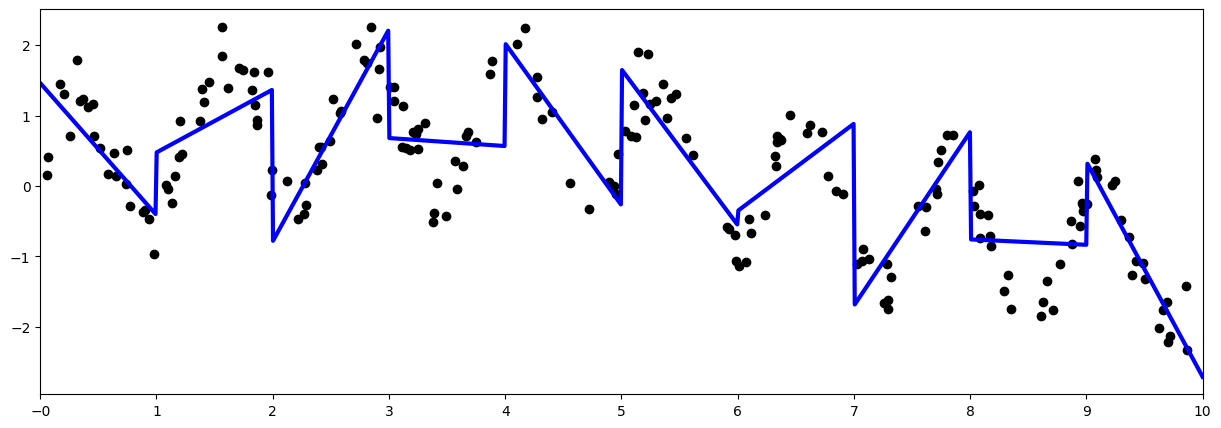

In [21]:
X2 = np.hstack([X_binned_1, X.reshape(-1,1) * X_binned_1]) # not matrix multiplication; it is element-wise multiplication with broadcasting.
print('Features matrix shape:', X2.shape)
model2 = LinearRegression().fit(X2, y)

line2 = np.hstack([line_binned, line.reshape(-1,1) * line_binned])
ypred1 = model2.predict(line2)

plt.figure(figsize=(15,5))
plt.scatter(X, y, c='k')
plt.plot(line, ypred1, c='blue', linewidth=3, label='linear model')
plt.xlim(0,10)
plt.xticks(bins);

We can further improve this by considering a different binning technique -- more bins or something like that.

So, considering binned features for linear models improves their flexibility and overall modelling power. Another technique is adding polynomial features, of course!

## Univariate Nonlinear Transformations

Functions like `sin`, `cos`, `log`, and `exp` are useful transformations on the features other than the polynomials `1, x, x^2, x^3, ...` that we have previously considered.

While tree-based models only care about the ordering of features, linear models are highly dependent on the scale and distribution of the features; if there are nonlinearities between the features, we can't expect it to perform well.

We can eliminate nonlinearities with `sin`, `log`, or `exp` transformations on the features.
- `log` and `exp` helps in adjusting the relative scales in the data
- `sin` is useful for periodic data.

**Example:** The rate constant $k$ for a given reaction is related to the temperature $T$ according to the Arrhenius equation: $$k = A\cdot \exp\left(-\frac{E_a}{RT}\right).$$ A classic reaction engineering problem is to determine the activation energy $E_a$ and the pre-exponential factor $A$ given $k$ vs. $T$ data, and the approach is to transform the data from $k$,$T$ to $\ln{k}$, $1/T$ before applying linear regression.

**Example: Integer Count Data**

Most models work when the data is loosely Gaussian distributed, i.e., when the histogram of each feature follows a bell-shaped curve. A transformation on the data that can make this hold is the `log` and `exp` transformations! A common case where this is helpful is when dealing with integer count data, e.g., user login count.

In [22]:
# Some synthetic integer count data
rnd = np.random.RandomState(0)
X_org = rnd.normal(size=(1000,3))
w = rnd.normal(size=3)

X = rnd.poisson(10 * np.exp(X_org))
y = np.dot(X_org, w)

print(X[:10])

[[ 56  18  27]
 [ 81  57   3]
 [ 25   9  11]
 [ 20  13  30]
 [ 27  13  13]
 [ 18  46   7]
 [ 12   3   1]
 [ 21  20   2]
 [109   1   6]
 [  7  55  41]]


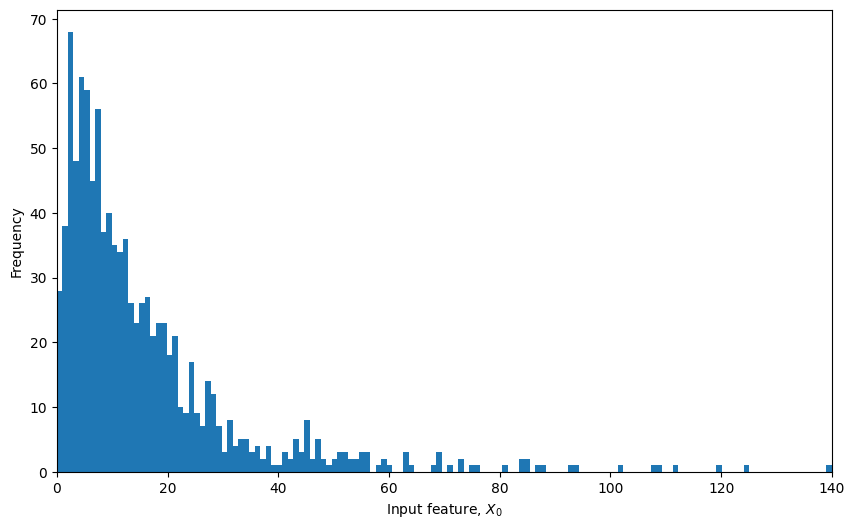

In [23]:
plt.figure(figsize=(10,6))
plt.hist(X[:,0], bins = np.amax(X[:,0])+1)
#plt.rcParams['text.usetex'] = False
plt.xlabel(r'Input feature, $X_0$')
plt.ylabel('Frequency')
plt.xlim(0,140);

As can be seen, data for feature $X_0$ is skewed to the left; it's asymmetrical. We expect the same behavior for the features $X_1, X_2$.

These types of distribution are common in practice, but these are the ones that linear models can't handle very well.

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
score = Ridge().fit(X_train, y_train).score(X_test, y_test)
print(f'Score of ridge regression on raw data: {score: .3f}')

Score of ridge regression on raw data:  0.622


Applying a logarithmic transformation on the features can help!

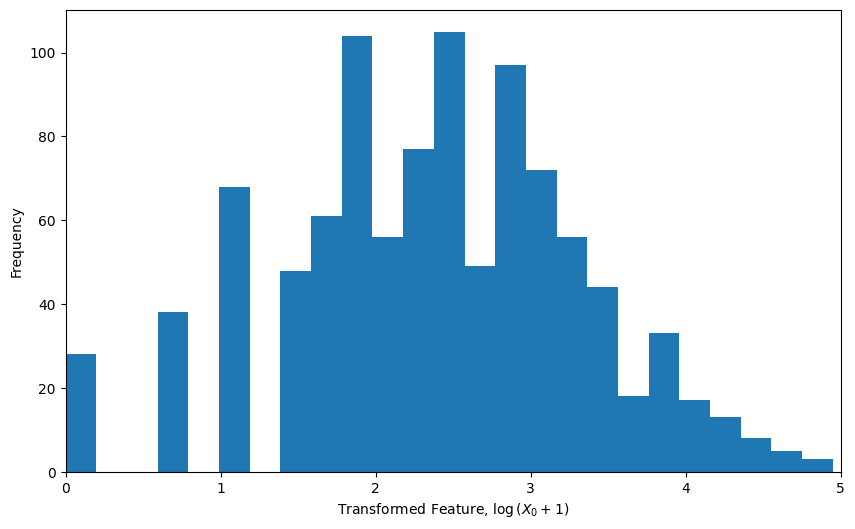

In [25]:
X_log = np.log(X + 1)

plt.figure(figsize=(10,6))
plt.hist(X_log[:,0], bins=25)
#plt.rcParams['text.usetex'] = False
plt.xlabel(r'Transformed Feature, $\log{(X_0 + 1)}$')
plt.ylabel('Frequency')
plt.xlim(0,5);

As can be seen, applying a logarithmic transformation on the feature results in a more symmetrical data; one that resembles a bell-curve or a Gaussian distribution.

Let's try another regression and see its performance on this transformed data.

In [26]:
X_train_log, X_test_log, y_train, y_test = train_test_split(X_log, y, random_state=0)
score_log = Ridge().fit(X_train_log, y_train).score(X_test_log, y_test)
print(f'Score of ridge regression on raw data: {score_log: .3f}')

Score of ridge regression on raw data:  0.875


Points to keep in mind:
- In the above example, the three features exhibit the same asymmetries, so we applied the same transformation to all of them. This is rarely the case in real-world datasets: The features often have different properties that require different treatments.

- Univariate transformations are irrelevent to tree-based models; they might only be needed for linear models.

- Binning, polynomials, and interactions can have a huge influence on how a model performs on a dataset, especially for less complex models like linear models and naive Bayes models; Tree-based models don't require such treatment most of the time; SVMs, nearest neighbors, and neural networks might sometimes benefit.

## Automatic Feature Selection

There are three basic strategies in determining how good a feature is:

1. Univariate statistics
2. Model-based selection
3. Iterative selection

These are supervised methods, so the target variable is needed for fitting the model. So, split the data into training and test sets and apply feature selection only on the training set.

### Univariate Statistics

Compute if there is a statistically significant relationship between each feature and the target, and select the ones that are related with the highest confidence. For classification, this is also called *Analysis of Variance (ANOVA)*.

Key properties:
- These tests are univariate: each feature is treated individually, and a feature will be discarded if it is only informative when combined with another feature.
- Fast to compute.
- Completely independent of the model to be used after feature selection.

In scikit-learn, we need to choose...
1. A test: usually `f_classif` for classification, and `f_regression` for regression.
2. A method to discard features based on p-values: the simplest ones are `SelectKBest` and `SelectPercentile`. 

Features matrix shape: (569, 80) 
Target shape: (569,) 
 
Original X_train shape: (290, 80)
New X_train shape: (290, 40)


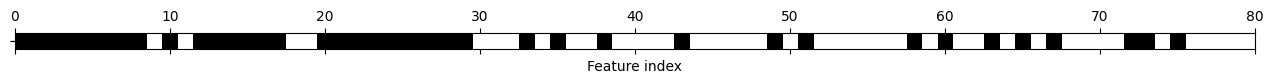

Test score (original features): 0.910
Test score (selected features): 0.925


In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
FeatureSelect = SelectPercentile(percentile=50) # the half with the highest scores will be kept
model = LogisticRegression()

# Add noise features to dataset
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data),50)) # 50 noise features
X = np.hstack([cancer.data, noise]) # Total of 80 features, 30 from original, 50 from noise
y = cancer.target
print('Features matrix shape:', X.shape, '\nTarget shape:', y.shape, '\n ')

# Separate data to training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.49)

# Feature selection
FeatureSelect.fit(X_train, y_train)
X_train_new = FeatureSelect.transform(X_train)
X_test_new = FeatureSelect.transform(X_test)
print('Original X_train shape:', X_train.shape)
print('New X_train shape:', X_train_new.shape)

# Visualize feature selection
mask = FeatureSelect.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature index')
plt.yticks([-0.01,0.01], labels=['',''])
plt.xlim(0,80)
plt.show()

# Modelling
model.fit(X_train, y_train)
print('Test score (original features): {:.3f}'.format(model.score(X_test, y_test)))
model.fit(X_train_new, y_train)
print('Test score (selected features): {:.3f}'.format(model.score(X_test_new, y_test)))

In this case, feature selection by univariate statistics improved performance; most of the noise features were removed but some original features were lost.

Outcomes on real world datasets might be mixed, but univariate feature selection is still helpful for removing uninformative features.

### Model-Based Feature Selection

This type of feature selection uses a supervised model to determine which features are important.
- The supervised model used for feature selection need not be the one used for classification/regression
- It requires for the supervised model to be able to weigh feature importance.
  - Decision trees and decision tree-based models in sklearn have a `feature_importance_` attribute
  - Linear models and their generated coefficients can also be used. In particular, L1-regularized linear models have 1 or 0 as the values of their coefficients.
- It can capture interactions (if the model can) since it considers all features at once.

Original X_train shape: (290, 80)
New X_train shape: (290, 40)


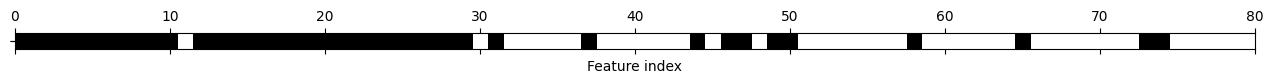

In [40]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Feature selection model using the random forest classifier
FeatureSelect_1 = SelectFromModel(
    estimator = RandomForestClassifier(n_estimators = 100, random_state=42),
    threshold = 'median'
)

# Feature select on cancer dataset
FeatureSelect_1.fit(X_train,y_train)
X_train_new_1 = FeatureSelect_1.transform(X_train)
X_test_new_1 = FeatureSelect_1.transform(X_test)
print('Original X_train shape:', X_train.shape)
print('New X_train shape:', X_train_new.shape)

# Visualize feature selection
mask = FeatureSelect_1.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature index')
plt.yticks([-0.01,0.01], labels=['',''])
plt.xlim(0,80)
plt.show()

It captured more of the original features.

In [29]:
# Fit logistic regression and check the score
model.fit(X_train, y_train)
print('Test score (original features): {:.3f}'.format(model.score(X_test, y_test)))
model.fit(X_train_new_1, y_train)
print('Test score (selected features): {:.3f}'.format(model.score(X_test_new_1, y_test)))

Test score (original features): 0.910
Test score (selected features): 0.925


Performance of the logistic regression model has improved with the model-based feature selection.

### Iterative Feature Selection

Here, a series of models are built with varying numbers of features. There are two methods:
- Start with one feature and add the other features one-by-one until a stopping criterion is met.
- Start with all features and discard the others one-by-one until a stopping criterion is met.

One such iterative selector is Scikit-learn's **Recursive Feature Elimination** or RFE. It is of the second type of method and the stopping criterion is a prespecified number of features to be retained.

It's basically like a series of model-based feature selectors.

1.96 s ± 4.23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Original X_train shape: (290, 80)
New X_train shape: (290, 40)


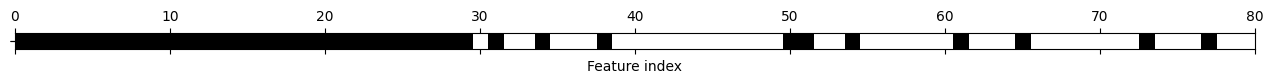

In [41]:
from sklearn.feature_selection import RFE

FeatureSelect_2 = RFE(
    estimator = RandomForestClassifier(n_estimators = 100, random_state=42),
    n_features_to_select = 40
)

# Feature select on cancer dataset
%timeit FeatureSelect_2.fit(X_train,y_train)
X_train_new_2 = FeatureSelect_2.transform(X_train)
X_test_new_2 = FeatureSelect_2.transform(X_test)
print('Original X_train shape:', X_train.shape)
print('New X_train shape:', X_train_new.shape)

# Visualize feature selection
mask = FeatureSelect_2.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature index')
plt.yticks([-0.01,0.01], labels=['',''])
plt.xlim(0,80)
plt.show()

It captured most of the original features, and was able to capture more than those in the previous trials.

Furthermore, it took an average of 1.98 seconds per loop, indicating that this type of feature selection is computationally expensive; much more than the previous ones.

In [42]:
# Fit logistic regression and check the score
model.fit(X_train, y_train)
print('Test score (original features): {:.3f}'.format(model.score(X_test, y_test)))
model.fit(X_train_new_2, y_train)
print('Test score (selected features): {:.3f}'.format(model.score(X_test_new_2, y_test)))

Test score (original features): 0.910
Test score (selected features): 0.943


We can aslo check the performance of the random forest classifier within the selector.

In [43]:
print('Random forest test score (original features): {:.3f}'.format(FeatureSelect_2.score(X_test, y_test)))

Random forest test score (original features): 0.950


The performance of the logistic regression model improved greatly with selected features, even becoming almost as good as a random forest classifier.

## Utilizing Expert Knowledge

### Predicting bicycle rentals in front of Andrea's house - Citi Bike Dataset

Andrea is the name of one of the authors of the book I'm reading (Introduction to Machine Learning).

**Task**: Predict for a given time and day how many people will rent a bike in front of Andrea's house -- so he knows if any bikes will be left for him.

Dataset was downloaded from the [repository](https://github.com/amueller/introduction_to_ml_with_python/tree/main/data) provided by the authors to accompany the book.

Dataset is a subset of the [CitiBike System Data](https://www.kaggle.com/datasets/sujan97/citibike-system-data) containing data for August 2015 and for the CitiBike station near Andrea's house: E 2 St & Avenue B

In [33]:
path = '~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/citibike.csv'
citibike = pd.read_csv(path, index_col='starttime', parse_dates=True)
citibike.head()

,tripduration,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
starttime,,,,,,,,,,,,,,
2015-08-01 01:19:15,3117,8/1/2015 02:11:12,301,E 2 St & Avenue B,40.722174,-73.983688,301,E 2 St & Avenue B,40.722174,-73.983688,18070,Subscriber,1986.0,1
2015-08-01 01:27:30,690,8/1/2015 01:39:00,301,E 2 St & Avenue B,40.722174,-73.983688,349,Rivington St & Ridge St,40.718502,-73.983299,19699,Subscriber,1985.0,1
2015-08-01 01:38:49,727,8/1/2015 01:50:57,301,E 2 St & Avenue B,40.722174,-73.983688,2010,Grand St & Greene St,40.721655,-74.002347,20953,Subscriber,1982.0,1
2015-08-01 06:06:41,698,8/1/2015 06:18:20,301,E 2 St & Avenue B,40.722174,-73.983688,527,E 33 St & 2 Ave,40.744023,-73.976056,23566,Subscriber,1976.0,1
2015-08-01 06:24:29,351,8/1/2015 06:30:21,301,E 2 St & Avenue B,40.722174,-73.983688,250,Lafayette St & Jersey St,40.724561,-73.995653,17545,Subscriber,1959.0,1


For the given task, only the bicycle count is needed. So I just used the `bikeid` and then resampled into three-hour intervals.

In [34]:
citibike = citibike['bikeid'].resample('3h').count().astype(float)
print('CitiBike data:\n{}'.format(citibike.head()))

CitiBike data:
starttime
2015-08-01 00:00:00     3.0
2015-08-01 03:00:00     0.0
2015-08-01 06:00:00     9.0
2015-08-01 09:00:00    41.0
2015-08-01 12:00:00    39.0
Freq: 3h, Name: bikeid, dtype: float64


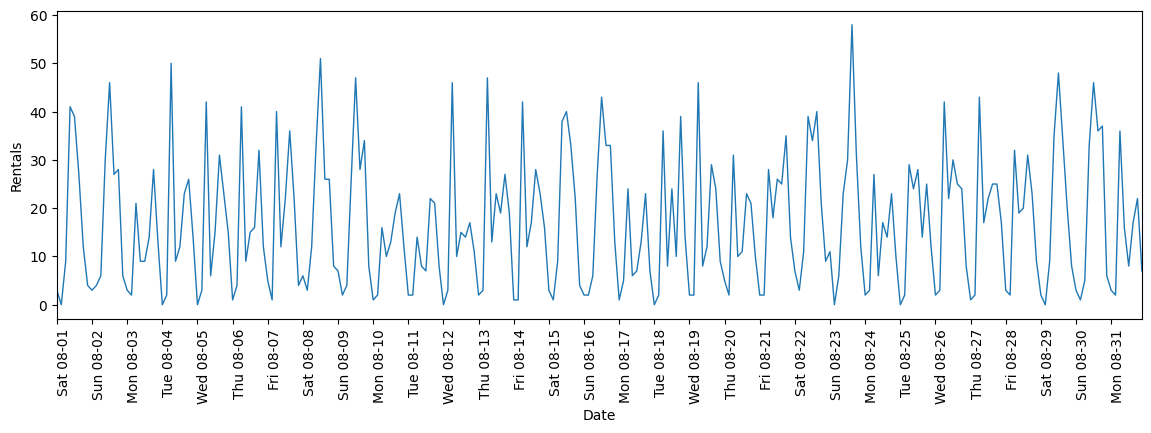

In [157]:
fig,ax = plt.subplots(1,1,figsize=(14,4))
ax.plot(citibike.index, citibike.values, linewidth=1)
ax.set_xlim(citibike.index.min(), citibike.index.max())
xticks = pd.date_range(start = citibike.index.min(),
                       end = citibike.index.max(),
                       freq = 'D')
ax.set_xticks(xticks, xticks.strftime("%a %m-%d"), rotation=90, ha='left')
ax.set_xlabel('Date')
ax.set_ylabel('Rentals');

When evaluating a prediction task on time-series data, it is desired to **learn from the past and predict for the future**. This leads to the consideration that the hold-out set should be the most recent fraction of the data.

So, here, the training set will be the oldest 184 samples (first 184 three-hour periods), while the test set will be the latest 64 samples.

#### Feature Representation (Trial 1)

Convert each three-hour period in seconds.

In [121]:
X = citibike.index.to_numpy(dtype="int").reshape(-1,1)
y = citibike.values
X.shape, y.shape

((248, 1), (248,))

In [160]:
from sklearn.ensemble import RandomForestRegressor

def score_and_plot(X, y, regressor):
    # Constant training set size of 184 samples
    train_size = 184
    xticks = pd.date_range(start = citibike.index.min(),
                       end = citibike.index.max(),
                       freq = 'D')
    X_train, X_test, y_train, y_test = (X[:184], X[184:], y[:184], y[184:])

    # Fit regressor on data, predict values for plotting, R^2 test score
    regressor.fit(X_train, y_train)
    train_pred = regressor.predict(X_train)
    test_pred = regressor.predict(X_test)
    score = regressor.score(X_test, y_test)

    # Print test score and plot data
    print('Test-set R^2: {:.2f}'.format(score))
    plt.figure(figsize=(14,4))
    plt.plot(citibike.index[:train_size], y_train, label='train', c='b')
    plt.plot(citibike.index[train_size:], y_test, label='test', c='r')
    plt.plot(citibike.index[:train_size], train_pred, label='prediction_train', c='lime', ls='--')
    plt.plot(citibike.index[train_size:], test_pred, label='prediction_test', c='cyan', ls='--')
    plt.xticks(xticks, xticks.strftime("%a %m-%d"), rotation=90, ha='left')
    plt.xlim(xticks.min(), xticks.max())
    plt.xlabel('Date')
    plt.ylabel('Rentals')
    plt.legend(bbox_to_anchor=(1,0.3))

Test-set R^2: -0.04


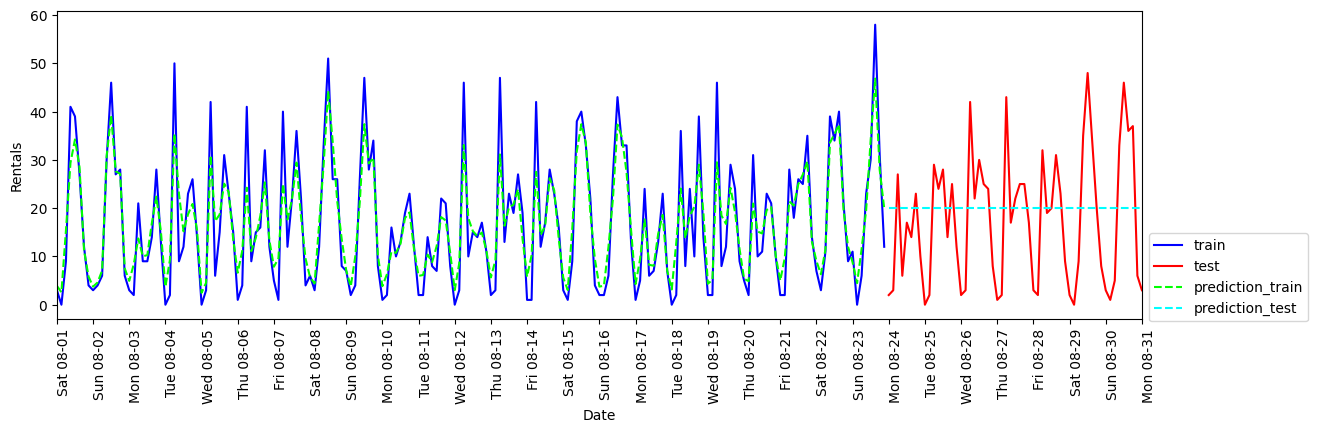

In [161]:
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
score_and_plot(X,y,regressor)

The random forest regressor performed well on the training set, as is typical of a tree-based model (or any model). However, the regressor scored very poorly on the test set; it predicts the number of bike rentals as a constant value on the test set.

We got a negative score on the test set, meaning the model did not learn anything at all!

The reason has to do with feature representation. <mark>Tree-based models like the random forest regressor cannot extrapolate outside the range of the training set.</mark> Its prediction for any date outside the range will be the value for the closest date in the training set.

Clearly we can find a better feature representation. And this is where **expert knowledge** can be used! (or in this case, common sense)
- Bike rentals is different each day of the week: More people rent bikes on weekends; many people rent on weekdays as well, but only at few periods of the day.
- Bike rentals vary each time of day: Almost no one rents very late at night or very early in the morning (duh); and the number of rentals peak at least once in the middle of the day.

#### Feature Representation (Trial 2)
Looking at the plot for the dataset, it looks like time of day and day of the week are two important factors. We aim to capture these daily and weekly patterns.

Test-set R^2: 0.84


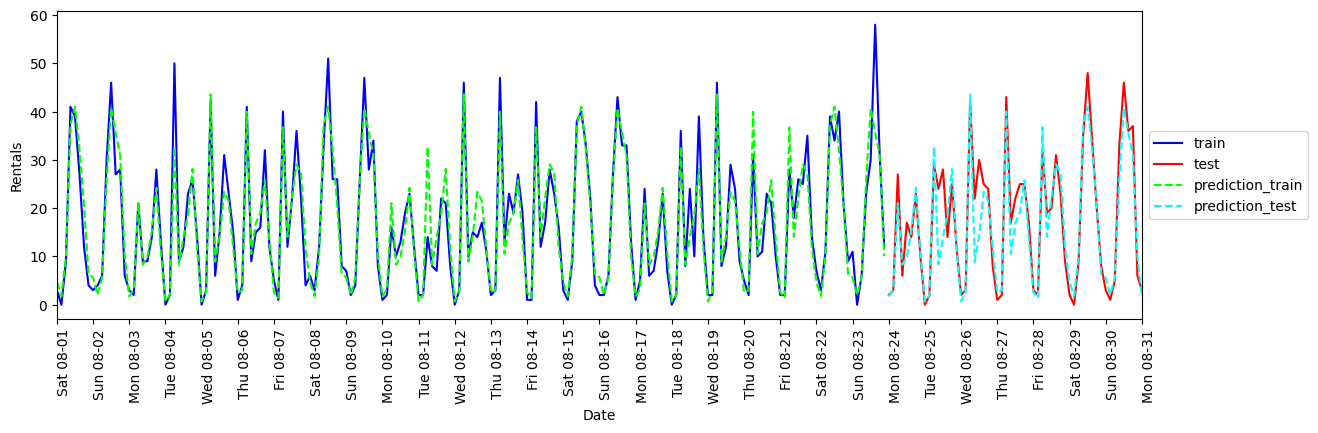

In [183]:
X_hour_week = np.hstack([citibike.index.hour.values.reshape(-1,1),
               citibike.index.dayofweek.values.reshape(-1,1)])
y = citibike.values

score_and_plot(X_hour_week, y, regressor)

And it did significantly better, and captured both daily and weekly pattern. What the model is likely learning is the mean of the rentals for a given time of day and day of week combination for the first 23 days of august. Such task does not need a complex model as random forest.

#### Considering a Linear Model

Test-set R^2: 0.13


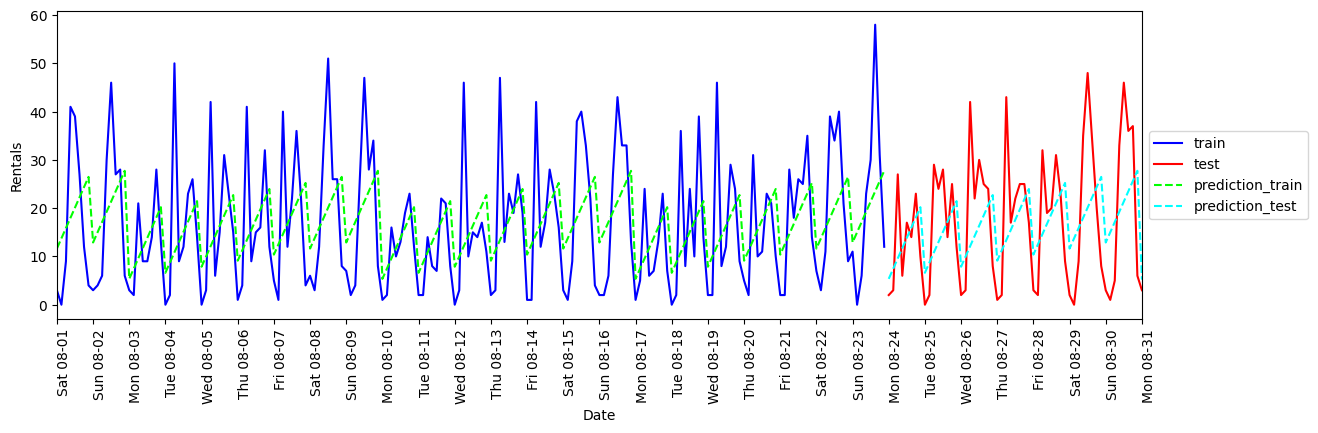

In [185]:
from sklearn.linear_model import LinearRegression, Ridge
score_and_plot(X_hour_week, y, LinearRegression())

The model learns two coefficients, one for time of day, another for day of week. It simply learned that bike rentals increase from monday to saturday at some constant rate, and that within each day, bike rentals increase with time of day. It does not consider other complex patterns.

This can be attributed to feature representation once again! Integers can encode categoricals. Clearly, day of week and time of day are categoricals. So, we must encode them as before.

#### Feature Representation (Trial 3)

Here we simply improve the `X_hour_week` representation so that the day of week and time of day features are encoded.

Test-set R^2: 0.62


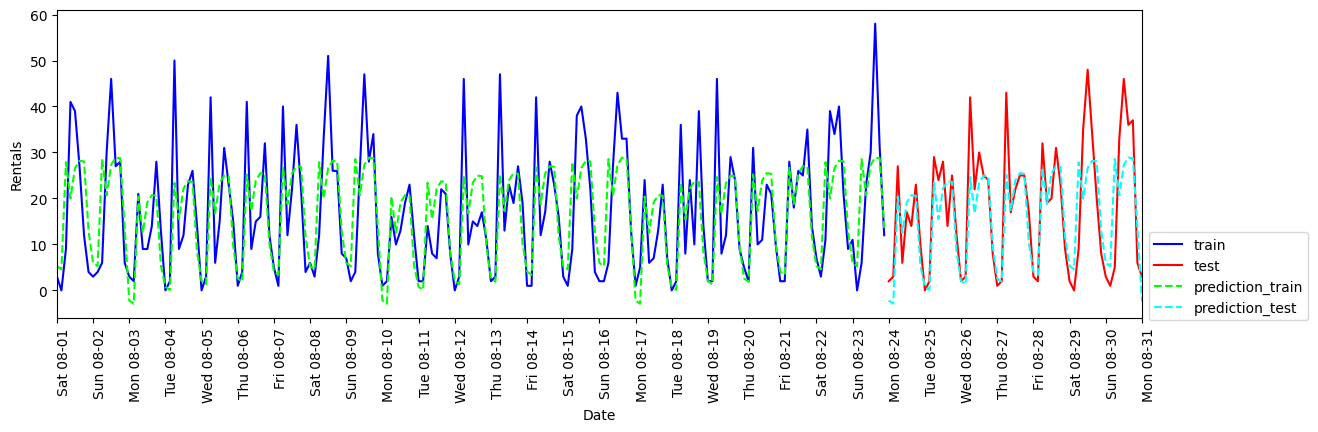

In [189]:
encoder = OneHotEncoder(sparse_output=False, dtype=int)
X_hour_week_encoded = encoder.fit_transform(X_hour_week)
score_and_plot(X_hour_week_encoded, y, LinearRegression())

Big improvement. In this case, the linear model learned one coefficient for each day of the week and one coefficient for each time of day. Thus, the model was able to learn the importance of each time of day and each day of the week in terms of bike rentals.

However, it captures only a constant pattern for the time of day within each day of the week.

#### Feature Representation (Trial 4)

One final improvement is for the linear model to capture different daily patterns for each day of the week! And this can be done with polynomial features to include interactions between time of day and and day of week features.

Test-set R^2: 0.85


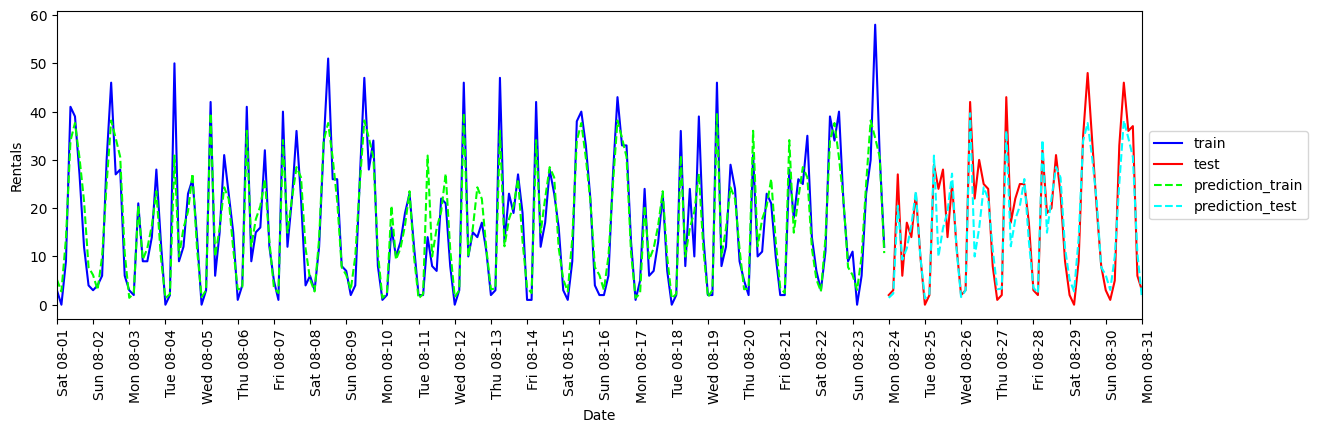

In [195]:
from sklearn.preprocessing import PolynomialFeatures

poly_transformer = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_hour_week_encoded_poly = poly_transformer.fit_transform(X_hour_week_encoded)
lr = Ridge()
score_and_plot(X_hour_week_encoded_poly, y, lr)

We have built a model that performs better than a random forest regressor simply by improving our feature representation, where we made sure that expert knowledge is considered. We can even plot the coefficients learned by the model, something that would not be possible for the random forest.

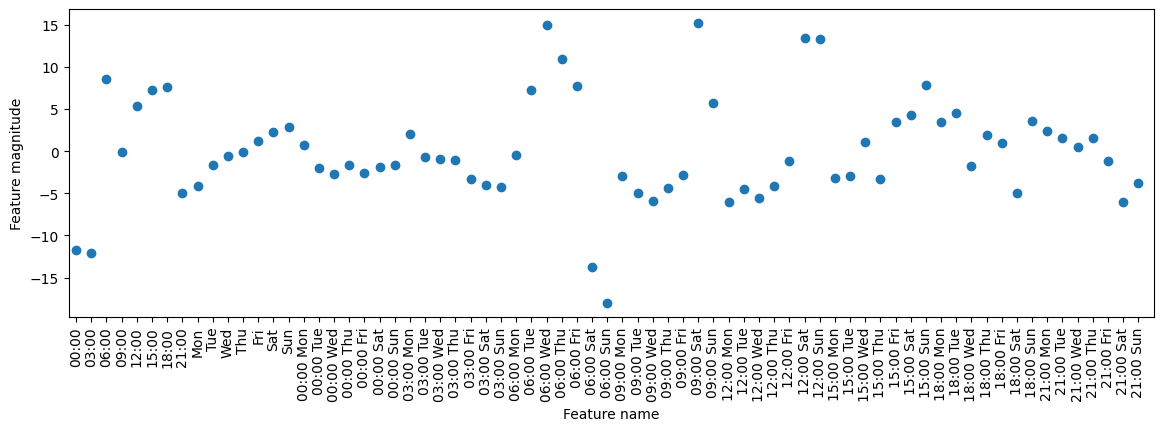

In [225]:
hour = ["%02d:00" % i for i in [0,3,6,9,12,15,18,21]]
day = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
features = hour + day

feature_names = poly_transformer.get_feature_names_out(features)
features_nonzero = feature_names[lr.coef_ != 0]
coef_nonzero = lr.coef_[lr.coef_ != 0]

plt.figure(figsize=(14,4))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel('Feature name')
plt.ylabel('Feature magnitude')
plt.xlim(-0.5,len(coef_nonzero));